# LSTM İle Tesla'nın Hisse Senedi Fiyat Tahmini

# 1- İş Problemi

- **Date**: İlgili İşlem Gününün tarihini temsil etmektedir.
- **Open**: İlgili işlem gününe ait Hisse başlangıç fiyatını temsil etmektedir.
- **High**: İlgili işlem gününe ait en yüksek fiyatı temsil etmektedir.
- **Low**: İlgili işlem gününe ait en düşük fiyatı temsil etmektedir.
- **Close**: İlgili işlem gününde hisse senedinin kapanış fiyatını temsil etmektedir.
- **Adj Close**: İlgili işlem gününe ait hisse senedinin düzeltilmiş kapanış fiyatını temsil etmektedir.
- **Volume**: İlgili işlem gününe ait işlem hacmi bilgisini temsil etmektedir.

# 2- Veriyi Anlamak

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings("ignore")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [36]:
df = pd.read_csv('./tsla_2025.csv')

In [37]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2010-06-28,1.13333,1.13333,1.13333,1.13333,0
1,2010-06-29,1.26667,1.66667,1.16933,1.59267,281749140
2,2010-06-30,1.71933,2.02800,1.55333,1.58867,257915910
3,2010-07-01,1.66667,1.72800,1.35133,1.46400,123447945
4,2010-07-02,1.53333,1.54000,1.24733,1.28000,77127105


In [38]:
# Veri setinin özelliklerini incelemek için bir fonksiyon tanımlayalım

def check_df(dataframe, head=5):
    print("############## Shape ##############")
    print(dataframe.shape)
    print("\n")

    print("############## Types ##############")
    print(dataframe.dtypes)
    print("\n")

    print("############## Head ##############")
    print(dataframe.head(head))
    print("\n")

    print("############## Tail ##############")
    print(dataframe.tail(head))
    print("\n")

    print("############## NA ##############")
    print(dataframe.isnull().sum())
    print("\n")

In [13]:
check_df(df)

############## Shape ##############
(3663, 6)


############## Types ##############
Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


############## Head ##############
         Date     Open     High      Low    Close     Volume
0  2010-06-28  1.13333  1.13333  1.13333  1.13333          0
1  2010-06-29  1.26667  1.66667  1.16933  1.59267  281749140
2  2010-06-30  1.71933  2.02800  1.55333  1.58867  257915910
3  2010-07-01  1.66667  1.72800  1.35133  1.46400  123447945
4  2010-07-02  1.53333  1.54000  1.24733  1.28000   77127105


############## Tail ##############
            Date    Open    High      Low   Close    Volume
3658  2025-01-13  383.21  403.79  380.070  403.31  67580494
3659  2025-01-14  414.34  422.64  394.540  396.36  84565022
3660  2025-01-15  409.90  429.80  405.661  428.22  81375460
3661  2025-01-16  423.49  424.00  409.130  413.82  68335151
3662  2025-01-17  421.50  439.74  419.750  426.50  949

# 3- Veriyi Hazırlamak

In [39]:
# Date'i datetime formatına çevirelim
df["Date"] = pd.to_datetime(df["Date"])

In [40]:
tesla_df = df[["Date", "Close"]]

In [41]:
tesla_df.head()

,Date,Close
0,2010-06-28,1.13333
1,2010-06-29,1.59267
2,2010-06-30,1.58867
3,2010-07-01,1.46400
4,2010-07-02,1.28000


In [42]:
print(f"Min Tarih: {tesla_df["Date"].min()}")
print(f"Max Tarih: {tesla_df["Date"].max()}")

Min Tarih: 2010-06-28 00:00:00
Max Tarih: 2025-01-17 00:00:00


In [ ]:
# Date sütununu index yapalım
tesla_df.set_index("Date", inplace=True)

In [47]:
tesla_df

,Close
Date,
2010-06-28,1.13333
2010-06-29,1.59267
2010-06-30,1.58867
2010-07-01,1.46400
2010-07-02,1.28000
...,...
2025-01-13,403.31000
2025-01-14,396.36000
2025-01-15,428.22000


In [48]:
# İleride lazım olacağı için bu df'in bir kopyasını alalım
result_df = tesla_df.copy()

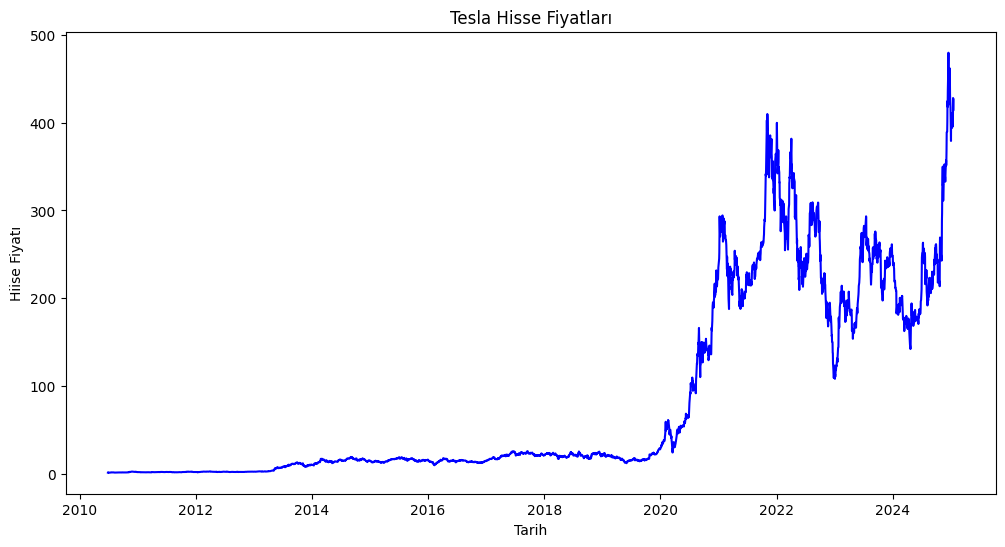

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(tesla_df["Close"], color="blue")
plt.ylabel("Hiise Fiyatı")
plt.xlabel("Tarih")
plt.title("Tesla Hisse Fiyatları")
plt.show()

In [50]:
# Nummpy array'e çevirelim
tesla_df = tesla_df.values

In [51]:
tesla_df.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [52]:
tesla_df[0:5]

array([[1.13333],
       [1.59267],
       [1.58867],
       [1.464  ],
       [1.28   ]])

In [61]:
tesla_df = tesla_df.astype("float32")

In [83]:
# train ve test setlerini ayıralım
# Normalde train_test_split ile ayırırız ama burada zaman serisi olduğu için rastgele olarak ayırmamamız gerekiyor.
# Bunun için bir fonksiyon tanımlayalım

def split_data(dataframe, test_size):
    a = int(round(len(dataframe) * (1 - test_size)))
    train = dataframe[:a]
    test = dataframe[a:]
    return train, test, a


In [84]:
train, test, a = split_data(tesla_df, 0.2)

In [85]:
print(f"Train Seti: {train.shape}")
print(f"Test Seti: {test.shape}")

Train Seti: (2930, 1)
Test Seti: (733, 1)


In [86]:
# Değerlerimizi 0-1 aralığına çekelim

scaler_train = MinMaxScaler(feature_range=(0, 1))
train = scaler_train.fit_transform(train)

scaler_test = MinMaxScaler(feature_range=(0, 1))
test = scaler_test.fit_transform(test)

In [87]:
train[0:5]

array([[0.00019564],
       [0.00131895],
       [0.00130917],
       [0.00100429],
       [0.00055432]], dtype=float32)

In [88]:
test[0:5]

array([[0.5371665 ],
       [0.49498874],
       [0.47762   ],
       [0.44583333],
       [0.39428663]], dtype=float32)

In [89]:
# İstediğimiz zaman periyotlarını oluşturmak için bir fonksiyon tanımlayalım

def create_features(data, lookback):
    x, y = [], []
    for i in range(lookback, len(data)):
        x.append(data[i-lookback:i, 0])  # Sadece Close fiyatını alıyoruz
        y.append(data[i, 0])  # Sonraki Close fiyatını tahmin
        
        return np.array(x), np.array(y)

In [94]:
lookback = 20  # 60 gün geriye bakacağız

x_train, y_train = create_features(train, lookback)
x_test, y_test = create_features(test, lookback)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (1, 20)
y_train shape: (1,)
x_test shape: (1, 20)
y_test shape: (1,)


In [91]:
x_train[0:5]

array([[1.9563898e-04, 1.3189483e-03, 1.3091667e-03, 1.0042877e-03,
        5.5431831e-04, 5.0548231e-05, 0.0000000e+00, 2.7064211e-04,
        2.6085996e-04, 2.0380691e-04, 3.8149580e-04, 6.5866718e-04,
        6.6681067e-04, 7.8908517e-04, 9.9614426e-04, 7.3364587e-04,
        7.2061154e-04, 8.4777665e-04, 8.9504803e-04, 8.3963317e-04]],
      dtype=float32)

In [92]:
y_train[0:5]

array([0.00077441], dtype=float32)

In [93]:
# LSTM kullanmak için verilerimizi 3 boyutlu hale getirelim
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

y_train = np.reshape(y_train, (y_train.shape[0], 1))
y_test = np.reshape(y_test, (y_test.shape[0], 1))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (1, 20, 1)
x_test shape: (1, 20, 1)
y_train shape: (1, 1)
y_test shape: (1, 1)


# 4- Modelleme

In [103]:
model = Sequential()

model.add(LSTM(units=50, activation="relu", input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Çıkış katmanı


In [104]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
# Optimizisayon ve Değerlendirme Metrikleri
model.compile(loss="mean_squared_error", optimizer="adam")

In [106]:
callbacks = [EarlyStopping(monitor='val_loss', patience=3, verbose=1, mode="min"),
             ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', save_best_only=True, mode='min', save_weights_only=False, verbose=1)]

In [107]:
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks, shuffle=False)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 8.7149e-07
Epoch 1: val_loss improved from inf to 0.31057, saving model to best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 8.7149e-07 - val_loss: 0.3106
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 9.8458e-07
Epoch 2: val_loss improved from 0.31057 to 0.30889, saving model to best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 9.8458e-07 - val_loss: 0.3089
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.1460e-07
Epoch 3: val_loss improved from 0.30889 to 0.30802, saving model to best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 3.1460e-07 - val_loss: 0.3080
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.8558e-06
Epoch 4: val_loss improved from 0.30802 to 0.30650, saving model to best_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.8558e-06 - val_loss: 0.3065
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.4637e-07
Epoch 5: val_loss improv